Finished A (Row-Sparse) N=8 Rep=1 | Time: 3.38s
Finished A (Row-Sparse) N=8 Rep=2 | Time: 3.50s
Finished A (Row-Sparse) N=10 Rep=1 | Time: 3.81s
Finished A (Row-Sparse) N=10 Rep=2 | Time: 4.64s
Finished A (Row-Sparse) N=16 Rep=1 | Time: 4.49s
Finished A (Row-Sparse) N=16 Rep=2 | Time: 4.69s
Finished A (Row-Sparse) N=25 Rep=1 | Time: 51.11s
Finished A (Row-Sparse) N=25 Rep=2 | Time: 45.16s
Finished A (Row-Sparse) N=32 Rep=1 | Time: 44.61s
Finished A (Row-Sparse) N=32 Rep=2 | Time: 60.72s
Finished A (Row-Sparse) N=50 Rep=1 | Time: 494.83s
Finished A (Row-Sparse) N=50 Rep=2 | Time: 604.26s
Finished A (Row-Sparse) N=100 Rep=1 | Time: 6527.94s
Finished A (Row-Sparse) N=100 Rep=2 | Time: 7532.44s
Finished B (Freq-Sparse) N=8 Rep=1 | Time: 3.85s
Finished B (Freq-Sparse) N=8 Rep=2 | Time: 3.76s
Finished B (Freq-Sparse) N=10 Rep=1 | Time: 4.86s
Finished B (Freq-Sparse) N=10 Rep=2 | Time: 4.78s
Finished B (Freq-Sparse) N=16 Rep=1 | Time: 4.65s
Finished B (Freq-Sparse) N=16 Rep=2 | Time: 4.66s
Fi

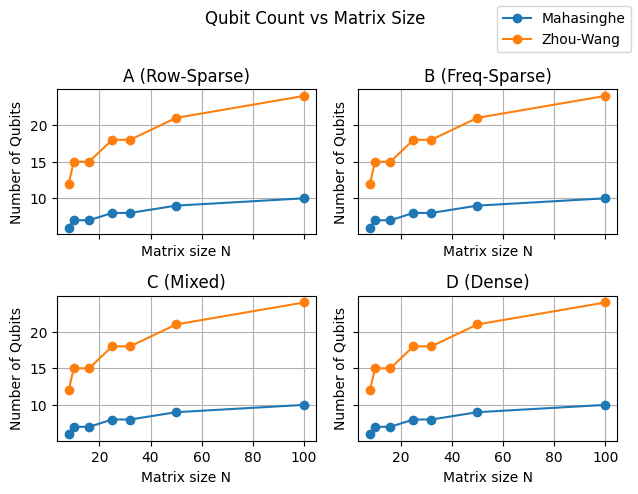

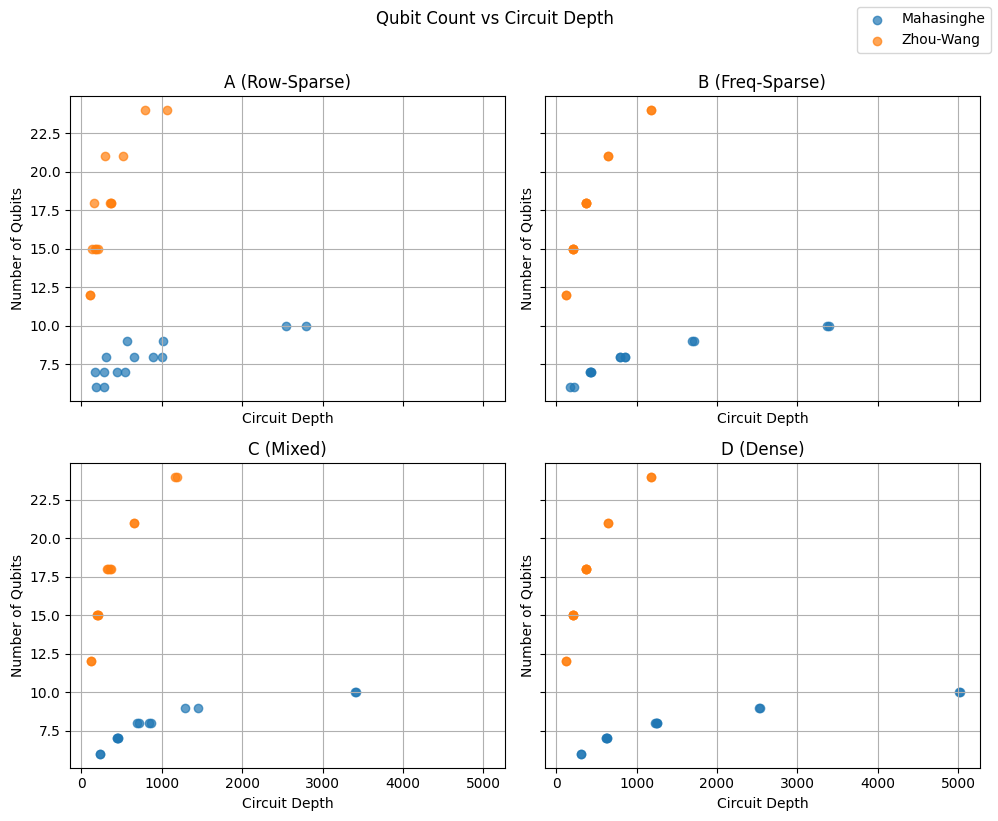

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import time
import matplotlib.pyplot as plt
from math import ceil, log2, pi
from scipy.linalg import toeplitz

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import QFTGate, PauliEvolutionGate, StatePreparation
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import SuzukiTrotter
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# IMPORTANT: Import fake provider for hardware-realistic benchmarking
from qiskit_ibm_runtime.fake_provider import FakeManilaV2 

# ============================================================
# Settings
# ============================================================
# Toggle this to True to run the simulation using a real IBM Fake Backend
USE_FAKE_BACKEND = False 

# ============================================================
# Utilities
# ============================================================
def next_pow2(n):
    return 1 << (n - 1).bit_length()

def fidelity(a, b):
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0: return 0
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return abs(np.vdot(a, b)) ** 2

def get_simulator():
    """Returns either a generic depolarizing simulator or a Fake Backend simulator."""
    if USE_FAKE_BACKEND:
        # Uses real topology, gate times, and noise profiles from IBM Manila
        return AerSimulator.from_backend(FakeManilaV2())
    else:
        # Standard generic depolarizing noise
        noise = NoiseModel()
        noise.add_all_qubit_quantum_error(depolarizing_error(0.005, 1), ["u", "rz", "sx", "x"])
        noise.add_all_qubit_quantum_error(depolarizing_error(0.01, 2), ["cx"])
        return AerSimulator(noise_model=noise)

# ============================================================
# Algorithm A: Mahasinghe–Wang (Noisy Fidelity)
# ============================================================
def mahasinghe_wang_bench(first_col, first_row, psi_in, shots=4096):
    N = len(first_col)
    n = next_pow2(N)
    n_sys = int(log2(n))
    two_n = 2 * n

    c_row = np.zeros(two_n, dtype=complex)
    c_row[:N] = first_row
    if N > 1: c_row[two_n - (N - 1):] = first_col[1:][::-1]
    lambda_c = np.fft.fft(c_row)
    k = max(np.abs(lambda_c).max(), 1.0)
    Lam = np.diag(lambda_c / k)
    sqrt_part = np.sqrt(np.eye(two_n) - Lam.conj() @ Lam + 0j)
    U_dil = np.block([[Lam, sqrt_part], [sqrt_part, -Lam.conj()]])
    H = np.block([[np.zeros_like(U_dil), U_dil], [U_dil.conj().T, np.zeros_like(U_dil)]])

    qr_sys, qr_pad = QuantumRegister(n_sys, "sys"), QuantumRegister(1, "pad")
    qr_dil, qr_herm = QuantumRegister(1, "dil"), QuantumRegister(1, "herm")
    qc = QuantumCircuit(qr_sys, qr_pad, qr_dil, qr_herm)
    
    psi_padded = np.zeros(n)
    psi_padded[:N] = psi_in
    qc.initialize(psi_padded / np.linalg.norm(psi_padded), qr_sys)
    qc.x(qr_herm)

    qc.append(QFTGate(n_sys + 1), [*qr_sys, *qr_pad])
    qc.append(PauliEvolutionGate(SparsePauliOp.from_operator(H), time=pi/2, synthesis=SuzukiTrotter()), [*qr_sys, *qr_pad, qr_dil, qr_herm])
    qc.append(QFTGate(n_sys + 1).inverse(), [*qr_sys, *qr_pad])

    tqc = transpile(qc, basis_gates=["cx", "u", "rz", "sx", "x"], optimization_level=3)
    qc_m = tqc.copy()
    qc_m.measure_all()
    
    counts = get_simulator().run(qc_m, shots=shots).result().get_counts()

    noisy_vector = np.zeros(N, dtype=complex)
    total_success = 0
    for bstr, count in counts.items():
        bits = bstr.replace(" ", "")[::-1]
        if bits[n_sys:n_sys+3] == "000":
            idx = int(bits[:n_sys], 2)
            if idx < N:
                noisy_vector[idx] = np.sqrt(count)
                total_success += count

    classical = toeplitz(first_col, first_row) @ (psi_in / np.linalg.norm(psi_in))
    total_cnots = tqc.count_ops().get('cx', 0)
    
    return fidelity(classical, noisy_vector), total_success/shots, total_cnots, tqc.num_qubits, tqc.depth()

# ============================================================
# Algorithm B: Zhou–Wang (Noisy Fidelity)
# ============================================================
def add_vbe_robust(qc, ctrl, target, aux):
    n = len(ctrl)
    for i in range(n - 1):
        qc.ccx(ctrl[i], target[i], aux[i + 1])
        qc.cx(ctrl[i], target[i])
        if i > 0: qc.ccx(target[i], aux[i], aux[i + 1])
    qc.cx(ctrl[n - 1], target[n - 1])
    qc.cx(aux[n - 1], target[n - 1])
    for i in reversed(range(n - 1)):
        if i > 0: qc.ccx(target[i], aux[i], aux[i + 1])
        qc.cx(ctrl[i], target[i])
        qc.ccx(ctrl[i], target[i], aux[i + 1])
        qc.cx(ctrl[i], target[i])
        if i > 0: qc.cx(aux[i], target[i])

def zhou_wang_bench(first_col, first_row, psi_in, shots=4096):
    N = len(first_col)
    L_sys = ceil(log2(N))
    M = 2 ** (L_sys + 1)
    L_orc = int(log2(M))
    
    c = np.concatenate([[first_col[0]], first_col[1:], np.zeros(M - (2*N - 1)), first_row[1:][::-1]])
    alpha = np.sum(np.abs(c))

    q_orc, q_blk = QuantumRegister(L_orc, "orc"), QuantumRegister(1, "blk")
    q_sys, q_aux = QuantumRegister(L_sys, "sys"), QuantumRegister(L_orc, "aux")
    qc = QuantumCircuit(q_orc, q_blk, q_sys, q_aux)

    # Move psi_pad definition UP here so the Prep CNOT counter can use it
    psi_pad = np.zeros(2 ** L_sys)
    psi_pad[:N] = psi_in

    # --- ISOLATE CNOT COUNTS  ---
    # 1. Oracle Prep CNOTs
    qc_prep = QuantumCircuit(q_orc, q_blk, q_sys, q_aux)
    qc_prep.append(StatePreparation(psi_pad / np.linalg.norm(psi_pad)), q_sys)
    qc_prep.append(StatePreparation(np.sqrt(np.abs(c)/alpha)), q_orc)
    t_prep = transpile(qc_prep, basis_gates=["u", "rz", "sx", "x", "cx"], optimization_level=3)
    cnots_prep = t_prep.count_ops().get('cx', 0)
    
    # 2. Adder CNOTs
    qc_adder = QuantumCircuit(q_orc, q_blk, q_sys, q_aux)
    add_vbe_robust(qc_adder, q_orc, list(q_sys) + list(q_blk), q_aux)
    t_adder = transpile(qc_adder, basis_gates=["u", "rz", "sx", "x", "cx"], optimization_level=3)
    cnots_adder = t_adder.count_ops().get('cx', 0)
    
    # 3. Uncomputation CNOTs
    qc_uncomp = QuantumCircuit(q_orc)
    qc_uncomp.append(StatePreparation(np.sqrt(np.abs(c)/alpha)).inverse(), q_orc)
    t_uncomp = transpile(qc_uncomp, basis_gates=["u", "rz", "sx", "x", "cx"], optimization_level=3)
    cnots_uncomp = t_uncomp.count_ops().get('cx', 0)
    # ------------------------------------------

    # Build full circuit
    qc.append(StatePreparation(psi_pad / np.linalg.norm(psi_pad)), q_sys)
    qc.append(StatePreparation(np.sqrt(np.abs(c)/alpha)), q_orc)
    add_vbe_robust(qc, q_orc, list(q_sys) + list(q_blk), q_aux)
    qc.append(StatePreparation(np.sqrt(np.abs(c)/alpha)).inverse(), q_orc) 
    
    tqc = transpile(qc, basis_gates=["u", "rz", "sx", "x", "cx"], optimization_level=3)
    qc_m = tqc.copy()
    qc_m.measure_all()
    
    counts = get_simulator().run(qc_m, shots=shots).result().get_counts()

    noisy_vector = np.zeros(N, dtype=complex)
    total_success = 0
    for bstr, count in counts.items():
        bits = bstr.replace(" ", "")[::-1]
        orc_ok = bits[:L_orc] == "0"*L_orc
        blk_ok = bits[L_orc] == "0"
        aux_ok = bits[L_orc+1+L_sys:] == "0"*L_orc
        if orc_ok and blk_ok and aux_ok:
            idx = int(bits[L_orc+1 : L_orc+1+L_sys], 2)
            if idx < N:
                noisy_vector[idx] = np.sqrt(count)
                total_success += count

    classical = toeplitz(first_col, first_row) @ (psi_in / np.linalg.norm(psi_in))
    total_cnots = tqc.count_ops().get('cx', 0)
    
    cnot_dict = {
        "Total": total_cnots,
        "Prep": cnots_prep,
        "Adder": cnots_adder,
        "Uncomp": cnots_uncomp
    }
    
    return fidelity(classical, noisy_vector), total_success/shots, cnot_dict, tqc.num_qubits, tqc.depth()

# ============================================================
# Matrix Generators
# ============================================================
def generate_category_a(n):
    num_active = min(2, 2 * n - 1)
    offsets = np.random.choice(np.arange(-(n - 1), n), size=num_active, replace=False)
    data = [np.random.rand(n - abs(off)) for off in offsets]
    return sp.diags(data, offsets, shape=(n, n), format="csr")

def generate_category_b(n):
    num_freqs = max(1, n // 4)
    freqs = np.random.choice(n, size=num_freqs, replace=False)
    spectrum = np.zeros(n, dtype=complex)
    spectrum[freqs] = np.random.rand(num_freqs) + 1j*np.random.rand(num_freqs)
    first_col = np.fft.ifft(spectrum).real
    return sp.csr_matrix(toeplitz(first_col, first_col))

def generate_category_c(n):
    col = np.zeros(n); col[0:2] = np.random.rand(2) 
    T = toeplitz(col, col)
    if n > 2:
        diag_idx = np.random.randint(2, n)
        T[np.arange(n-diag_idx), np.arange(diag_idx, n)] += 0.5 
    return sp.csr_matrix(T)

def generate_category_d(n):
    return sp.csr_matrix(toeplitz(np.random.rand(n), np.random.rand(n)))

# ============================================================
# Plotting Utilities
# ============================================================
def plot_qubits_vs_n_all_categories(df):
    categories = ["A (Row-Sparse)", "B (Freq-Sparse)", "C (Mixed)", "D (Dense)"]
    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]
        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Qubits"].mean()
            ax.plot(d.index, d.values, marker="o", label=algo)

        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Number of Qubits")
        ax.grid(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)
    fig.suptitle("Qubit Count vs Matrix Size", y=1.02)
    plt.tight_layout()
    plt.show()

def plot_qubits_vs_depth_all_categories(df):
    """New Plot requested by Reviewer 1: Qubit count plotted directly against circuit depth."""
    categories = ["A (Row-Sparse)", "B (Freq-Sparse)", "C (Mixed)", "D (Dense)"]
    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8))
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]
        for algo in sub["Algo"].unique():
            algo_data = sub[sub["Algo"] == algo]
            # Plot Depth (X) vs Qubits (Y)
            ax.scatter(algo_data["Depth"], algo_data["Qubits"], label=algo, alpha=0.7)

        ax.set_title(category)
        ax.set_xlabel("Circuit Depth")
        ax.set_ylabel("Number of Qubits")
        ax.grid(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)
    fig.suptitle("Qubit Count vs Circuit Depth", y=1.02)
    plt.tight_layout()
    plt.show()

# ============================================================
# Execution
# ============================================================
if __name__ == "__main__":
    SIZES = [8, 10, 16, 25, 32, 50, 100]
    REPETITIONS = 2
    CATEGORIES = {
        "A (Row-Sparse)": generate_category_a,
        "B (Freq-Sparse)": generate_category_b,
        "C (Mixed)":      generate_category_c,
        "D (Dense)":      generate_category_d
    }
    
    results = []
    lcu_cnot_breakdown_results = []
    
    for cat_name, gen_func in CATEGORIES.items():
        for n_val in SIZES:
            for rep in range(REPETITIONS):
                T = gen_func(n_val)
                col = T.getcol(0).toarray().flatten()
                row = T.getrow(0).toarray().flatten()
                psi = np.ones(n_val)

                # --- Benchmark Algorithm A ---
                start_a = time.time()
                fA, sA, tA_cnots, qA, dA = mahasinghe_wang_bench(col, row, psi)
                end_a = time.time()
                
                results.append({
                    "Category": cat_name, "N": n_val, "Algo": "Mahasinghe", 
                    "Fidelity": fA, "Success": sA, "Total CNOTs": tA_cnots,
                    "Qubits": qA, "Depth": dA, "Runtime": end_a - start_a
                })

                # --- Benchmark Algorithm B ---
                start_b = time.time()
                fB, sB, cnot_dict, qB, dB = zhou_wang_bench(col, row, psi)
                end_b = time.time()
                
                results.append({
                    "Category": cat_name, "N": n_val, "Algo": "Zhou-Wang", 
                    "Fidelity": fB, "Success": sB, "Total CNOTs": cnot_dict["Total"],
                    "Qubits": qB, "Depth": dB, "Runtime": end_b - start_b
                })
                
                # Save CNOT breakdown for table generation
                lcu_cnot_breakdown_results.append({
                    "Category": cat_name, "N": n_val, 
                    "Total CNOTs": cnot_dict["Total"],
                    "Oracle ($O_c$)": cnot_dict["Prep"],
                    "VBE Adder": cnot_dict["Adder"],
                    "Uncomputation": cnot_dict["Uncomp"]
                })
                
                print(f"Finished {cat_name} N={n_val} Rep={rep+1} | Time: {end_b - start_a:.2f}s")

    df = pd.DataFrame(results)
    df_cnots = pd.DataFrame(lcu_cnot_breakdown_results)
    
    summary = df.groupby(['Category', 'N', 'Algo'])[['Fidelity', 'Success', 'Total CNOTs', 'Depth', 'Runtime']].mean()
    print("\n--- FINAL BENCHMARK SUMMARY ---")
    print(summary.to_string())
    
    cnot_summary = df_cnots.groupby(['Category', 'N']).mean()
    print("\n--- LCU CNOT STAGE BREAKDOWN (FOR REVIEWER 1) ---")
    print(cnot_summary.to_string())

    # Generate both requested plots
    plot_qubits_vs_n_all_categories(df)
    plot_qubits_vs_depth_all_categories(df)

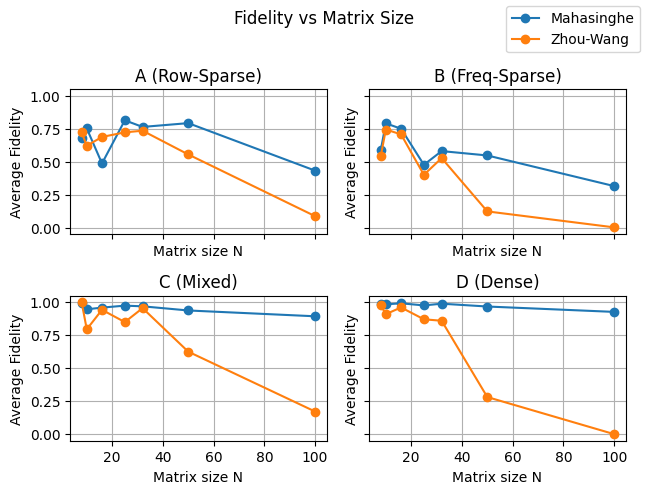

In [7]:
import matplotlib.pyplot as plt

def plot_fidelity_vs_n_all_categories(df):
    categories = df["Category"].unique()
    
    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]

        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Fidelity"].mean()
            ax.plot(d.index, d.values, marker="o", label=algo)

        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Average Fidelity")
        ax.grid(True)

    # One legend for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle("Fidelity vs Matrix Size", y=1.02)
    plt.tight_layout()
    plt.show()
plot_fidelity_vs_n_all_categories(df)


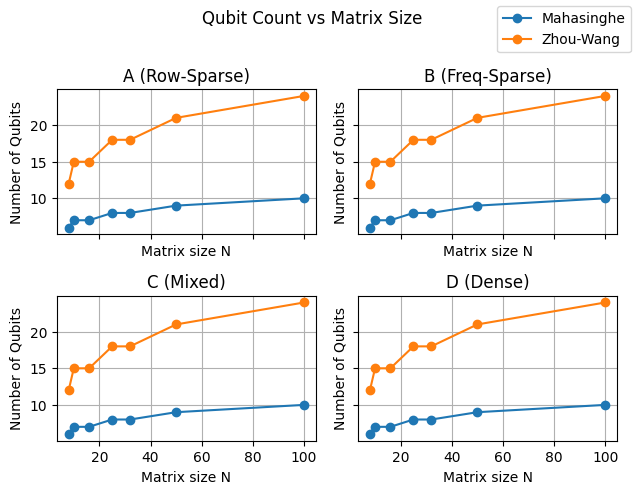

In [8]:
import matplotlib.pyplot as plt

def plot_qubits_vs_n_all_categories(df):
    categories = [
        "A (Row-Sparse)",
        "B (Freq-Sparse)",
        "C (Mixed)",
        "D (Dense)"
    ]

    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]

        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Qubits"].mean()
            ax.plot(d.index, d.values, marker="o", label=algo)

        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Number of Qubits")
        ax.grid(True)

    # One legend for the whole figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle(
        "Qubit Count vs Matrix Size ",
        y=1.02
    )

    plt.tight_layout()
    plt.show()
plot_qubits_vs_n_all_categories(df)


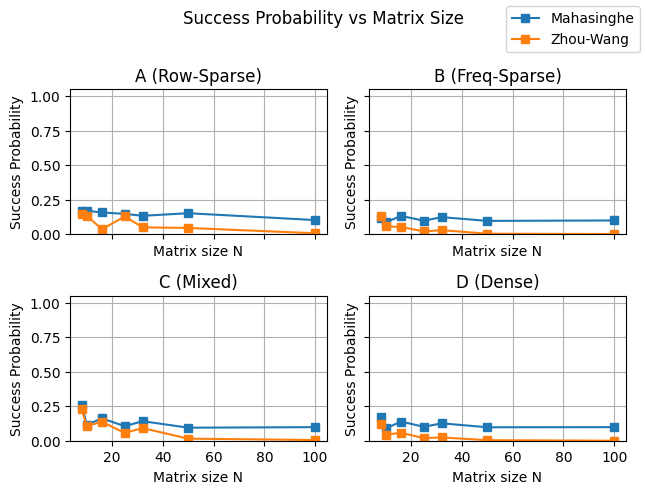

In [9]:
import matplotlib.pyplot as plt

def plot_success_vs_n_all_categories(df):
    categories = [
        "A (Row-Sparse)",
        "B (Freq-Sparse)",
        "C (Mixed)",
        "D (Dense)"
    ]

    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]

        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Success"].mean()
            ax.plot(d.index, d.values, marker="s", label=algo)

        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Success Probability")
        ax.set_ylim(0, 1.05)
        ax.grid(True)

    # Single legend for entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle(
        "Success Probability vs Matrix Size",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

plot_success_vs_n_all_categories(df)


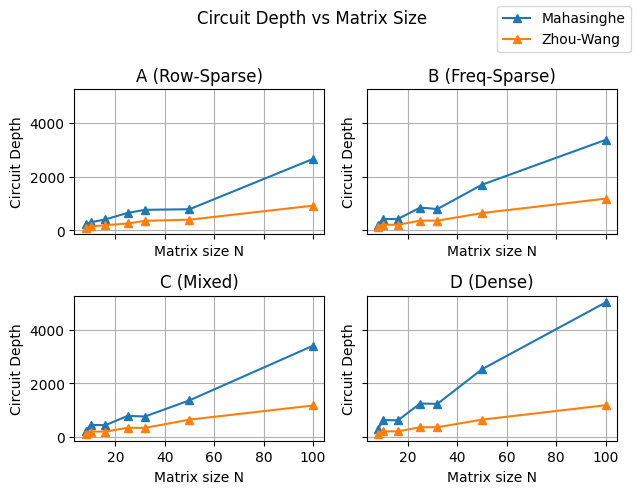

In [10]:
import matplotlib.pyplot as plt

def plot_depth_vs_n_all_categories(df):
    categories = [
        "A (Row-Sparse)",
        "B (Freq-Sparse)",
        "C (Mixed)",
        "D (Dense)"
    ]

    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]

        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Depth"].mean()
            ax.plot(d.index, d.values, marker="^", label=algo)

        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Circuit Depth")
        ax.grid(True)

    # One legend for entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle("Circuit Depth vs Matrix Size ", y=1.02)
    plt.tight_layout()
    plt.show()
plot_depth_vs_n_all_categories(df)


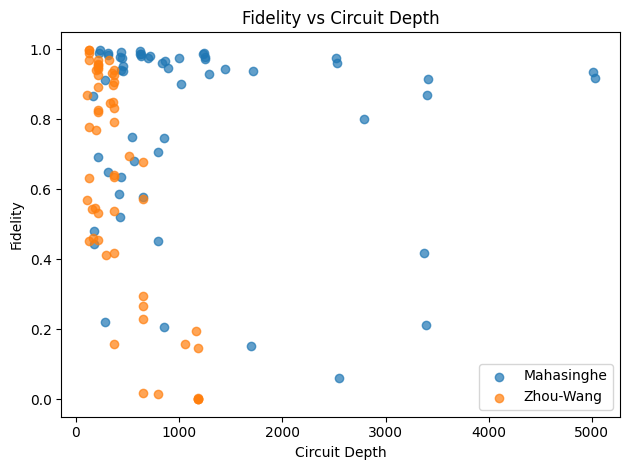

In [11]:
def plot_fidelity_vs_depth(df):
    for algo in df["Algo"].unique():
        sub = df[df["Algo"] == algo]
        plt.scatter(sub["Depth"], sub["Fidelity"], label=algo, alpha=0.7)

    plt.xlabel("Circuit Depth")
    plt.ylabel("Fidelity")
    plt.title("Fidelity vs Circuit Depth")
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_fidelity_vs_depth(df)

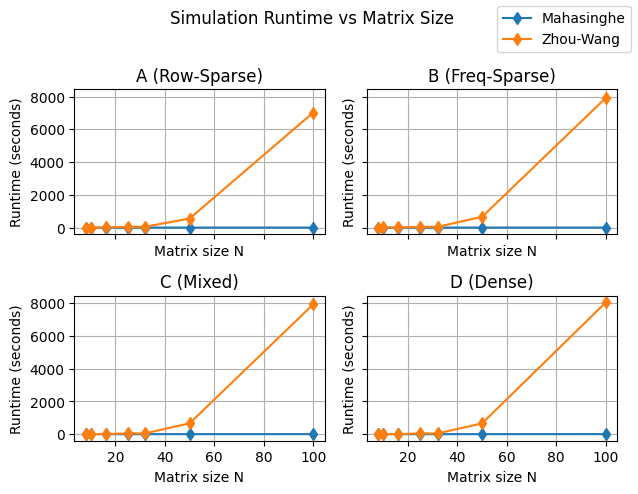

In [14]:
import matplotlib.pyplot as plt

def plot_runtime_vs_n_all_categories(df):
    categories = [
        "A (Row-Sparse)",
        "B (Freq-Sparse)",
        "C (Mixed)",
        "D (Dense)"
    ]

    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]

        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Runtime"].mean()
            ax.plot(d.index, d.values, marker="d", label=algo)

        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Runtime (seconds)")
        ax.grid(True)

    # Single legend for entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle(
        "Simulation Runtime vs Matrix Size ",
        y=1.02
    )

    plt.tight_layout()
    plt.show()
plot_runtime_vs_n_all_categories(df)



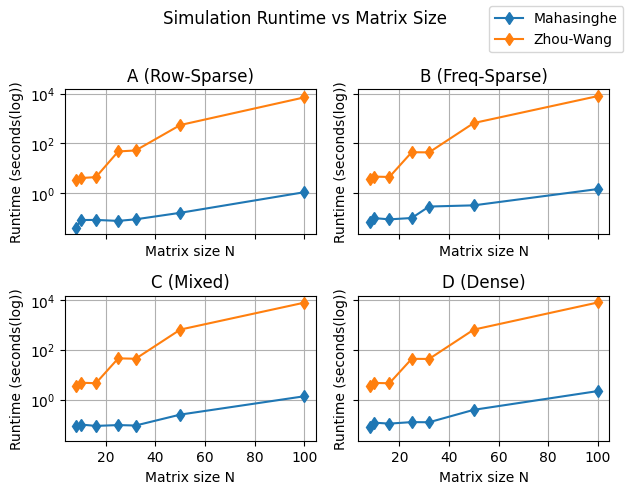

In [15]:
import matplotlib.pyplot as plt

def plot_runtime_vs_n_all_categories(df):
    categories = [
        "A (Row-Sparse)",
        "B (Freq-Sparse)",
        "C (Mixed)",
        "D (Dense)"
    ]

    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, category in zip(axes, categories):
        sub = df[df["Category"] == category]

        for algo in sub["Algo"].unique():
            d = sub[sub["Algo"] == algo].groupby("N")["Runtime"].mean()
            ax.plot(d.index, d.values, marker="d", label=algo)
        ax.set_yscale("log")
        ax.set_title(category)
        ax.set_xlabel("Matrix size N")
        ax.set_ylabel("Runtime (seconds(log))")
        ax.grid(True)

    # Single legend for entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=1)

    fig.suptitle(
        "Simulation Runtime vs Matrix Size ",
        y=1.02
    )

    plt.tight_layout()
    plt.show()
plot_runtime_vs_n_all_categories(df)



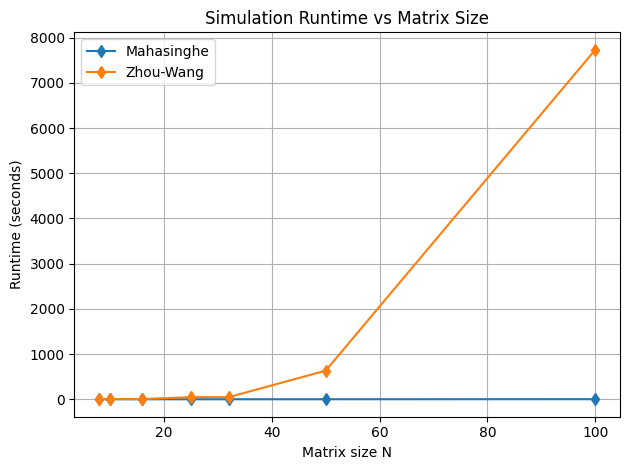

In [16]:
def plot_runtime_vs_n(df):
    for algo in df["Algo"].unique():
        d = df[df["Algo"] == algo].groupby("N")["Runtime"].mean()
        plt.plot(d.index, d.values, marker="d", label=algo)

    plt.xlabel("Matrix size N")
    plt.ylabel("Runtime (seconds)")
    plt.title("Simulation Runtime vs Matrix Size")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_runtime_vs_n(df)

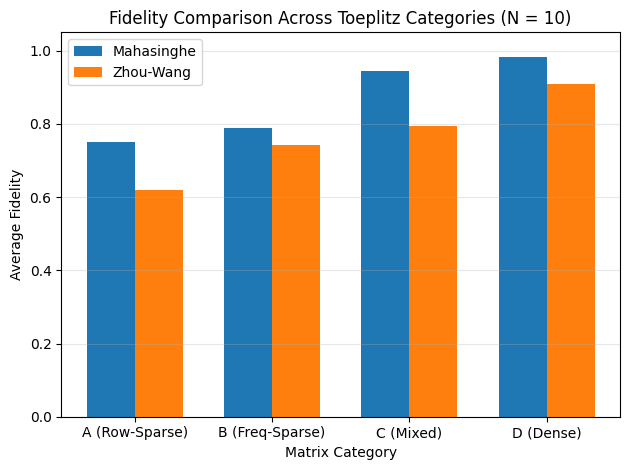

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fidelity_vs_category(df, fixed_n):
    categories = [
        "A (Row-Sparse)",
        "B (Freq-Sparse)",
        "C (Mixed)",
        "D (Dense)"
    ]

    sub = df[df["N"] == fixed_n]
    grouped = sub.groupby(["Category", "Algo"])["Fidelity"].mean().unstack()

    grouped = grouped.loc[categories]  # enforce order

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots()

    ax.bar(x - width/2, grouped.iloc[:, 0], width, label=grouped.columns[0])
    ax.bar(x + width/2, grouped.iloc[:, 1], width, label=grouped.columns[1])

    ax.set_xlabel("Matrix Category")
    ax.set_ylabel("Average Fidelity")
    ax.set_title(f"Fidelity Comparison Across Toeplitz Categories (N = {fixed_n})")
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1.05)
    ax.legend()

    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_fidelity_vs_category(df, fixed_n=10)
